In [66]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [71]:
# go more complex
a =2.0
b = -3.0
c = 10.0
d = a *b +c
print(d)

4.0


In [148]:
class Value:

    def __init__(self, data, _children = (), _op= '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0
        self._backward = lambda: None 

    def __repr__(self):
        return f"Value(data={self.data}, op={self._op})" 
    
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1 ) / (math.exp(2*n) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += out.grad * (1- t**2)
        out._backward = _backward

        return out
    
    def exp(self):
        t = math.exp(self.data) 
        out = Value(t, (self, ), 'exp')
        def _backward():
            self.grad += out.grad * t
        out._backward = _backward

        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out =  Value(self.data**(other), (self, ), f'**{other}')
        def _backward():
            self.grad += out.grad * other * self.data ** (other-1)
        out._backward = _backward

        return out
    
    def __truediv__(self, other):
        return self * (other**-1)
    
    def neg(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return self + other
    


    def backward(self):
        # topological sort
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                topo.append(v) # reverse (noramlly after the for)
                for child in v._prev:
                    build_topo(child)
        build_topo(self)
        self.grad = 1
        for node in topo:
            node._backward()
x1 = Value(2.0, label = 'x1')
print(2*x1)
print(x1*2)

print(2+x1)
print(x1+2)

print(x1-1)
print(1-x1)

print(x1**2)

Value(data=4.0, op=*)
Value(data=4.0, op=*)
Value(data=4.0, op=+)
Value(data=4.0, op=+)
Value(data=1.0, op=+)
Value(data=3.0, op=+)
Value(data=4.0, op=**2)


In [135]:
a = Value(2)
b= Value(4)
a/b

Value(data=0.5, op=*)

In [127]:
b = a

In [129]:
b.grad =1
b.backward()

In [138]:
x1.grad

12.0

In [137]:
x2 = x1**3
x2.grad =1
x2.backward()

### Need to install graphviz
- pip install graphviz
- sudo apt update
- sudo apt install graphviz -y

Check by running:
- dot -V


In [94]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


# def draw_dot(root):
#   dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
#   nodes, edges = trace(root)
#   for n in nodes:
#     uid = str(id(n))
#     # for any value in the graph, create a rectangular ('record') node for it
#     dot.node(name = uid, label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
#     # if n._op:
#       # if this value is a result of some operation, create an op node for it
#       # dot.node(name = uid + n._op, label = n._op)
#       # and connect this node to it
#       # dot.edge(uid + n._op, uid)

#   for n1, n2 in edges:
#     # connect n1 to the op node of n2
#     dot.edge(str(id(n1)), str(id(n2)) )

#   return dot

In [113]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n= x1w1x2w2 + b; n.label = 'n'
o = n.tanh()


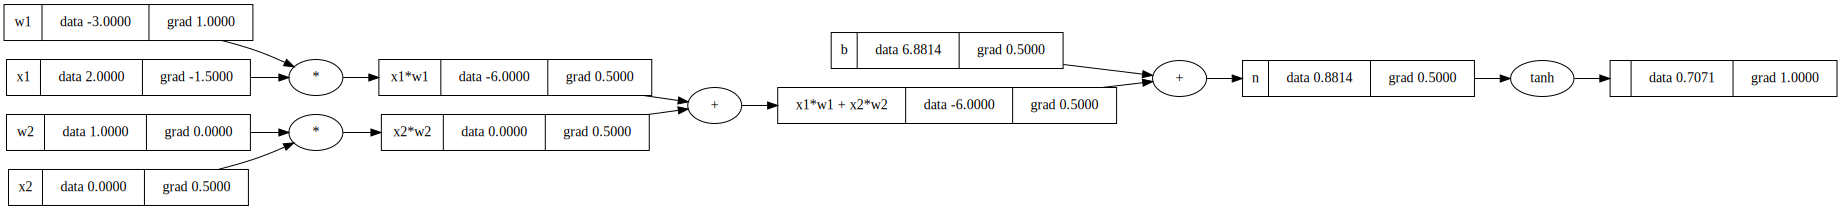

In [103]:
draw_dot(o)

In [102]:
o.backward()

In [114]:
o+1

Value(data=1.7071067811865475, op=+)